In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import GridSpec
import matplotlib.gridspec as gridspec
import glob
import pandas as pd
import math
import random
import scipy
from scipy.stats import mannwhitneyu

import seaborn as sns

plt.style.use('styleNB.mplstyle')



# Figure 3 - Supplemental Related - compass autocorrelation calculations using synthetic data


0.0
50
0.5
50
1.0
50
2.0
50
10.0
50


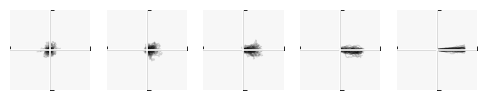

In [86]:
# f, ax = plt.subplots(1, 5, figsize=(8, 6))
# f, ax = plt.subplots(1, 5,figsize=(2*len(kappas),3))
f, ax = plt.subplots(1, 5,figsize=(1*len(kappas),1.5))


dict_ax = dict(zip(df.kappa.unique(), [0,1,2,3,4]))

for g, d in df.groupby('kappa'):
    print(g)
    trajectories = []
    count_cell = 0
    for i, d_ in d.groupby(['cell']):

        t0_x = d_[d_.frame == d_.frame.min()].x.values
        t0_y = d_[d_.frame == d_.frame.min()].y.values
        if len(t0_x) == 0 or len(t0_y) == 0:
            continue

        x_rel = d_.x.values - t0_x[0]
        y_rel = d_.y.values - t0_y[0]

        ax_ = ax[dict_ax[g]]
        ax_.plot(x_rel, y_rel, color='black', alpha=0.15, lw=0.8, zorder=10)

        # Optional: mark final point faintly
        #ax_.scatter(x_rel[-1], y_rel[-1], s=2, color='black', alpha=0.1, zorder=5)

        count_cell += 1
        
    print(count_cell)

    ax_ = ax[dict_ax[g]]

    # Draw white zero lines to emphasize axes
    ax_.axhline(0, color='white', lw=1.2, zorder=100)
    ax_.axvline(0, color='white', lw=1.2, zorder=100)

    # Enhance axis settings
    ax_.spines['left'].set_position(('data', 0))
    ax_.spines['bottom'].set_position(('data', 0))
    ax_.xaxis.set_label_coords(0.6, -0.05)
    ax_.yaxis.set_label_coords(0.0, 0.6)
    ax_.set_xlim(-200, 200)
    ax_.set_ylim(-200, 200)
    ax_.set_axisbelow(True)
    ax_.set_aspect('equal')  # Equal scaling for x and y
    ax_.set_facecolor('#f7f7f7')  # soft background for contrast

    # ax_.set_xlabel(r'x position ($\mu$m)')
    # ax_.set_ylabel(r'y position ($\mu$m)')

    # Hide y labels if not in leftmost column
    if dict_ax[g] > 0:
        ax_.set_ylabel('')
        ax_.tick_params(labelleft=False)

    # Keep axis labels only on outer left and bottom
    if dict_ax[g] > 0:
        ax_.set_ylabel('')

    # Remove all tick labels
    ax_.set_xticklabels([])
    ax_.set_yticklabels([])

    # Optional: reduce tick mark length
    ax_.tick_params(length=3)
            
plt.tight_layout()
# f.savefig('../../figures/20250523_compassauto_synthetic_tracks.pdf', bbox_inches='tight')

In [50]:
# Function for subsampling 
def parse_trajectories(df, frame_step=3):
    """
    Downsample trajectories from full-resolution filtered data.

    Parameters:
    - df: DataFrame containing full-resolution trajectories (already filtered)
    - frame_step: Interval to downsample (e.g., 1, 3, or more frames)

    Returns:
    - Downsampled DataFrame
    """
    df_out = pd.DataFrame()

    for g, d_ in df.groupby(['kappa', 'cell']):
        d_ = d_.copy().sort_values('frame')
        interval_frames = d_.frame.values[::frame_step]
        sampled = d_[d_['frame'].isin(interval_frames)]

        df_out = pd.concat([df_out, sampled], ignore_index=True)

    df_out['interval'] = df_out['frame']

    return df_out

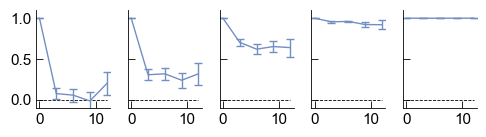

In [87]:
###############################
# Autocorrelation calculation
###############################

df_intervals_3 = parse_trajectories(df, frame_step=3)


def non_overlapping_normalized_autocorrelation(signal):
    n = len(signal)
    max_lag = n // 2
    autocorr = np.zeros(max_lag + 1)
    for lag in range(max_lag + 1):
        indices = np.arange(0, n - lag, lag + 1)
        pairs_a, pairs_b = signal[indices], signal[indices + lag]
        norm = np.sqrt(np.sum(pairs_a**2) * np.sum(pairs_b**2))
        autocorr[lag] = np.sum(pairs_a * pairs_b) / norm if norm else 0
    return autocorr
        

autocorr_list = []

for g, d in df_intervals_3.groupby(['kappa', 'cell']):
    d_sorted = d.sort_values('interval')
    vectors = np.diff(d_sorted[['x', 'y']].values, axis=0)  # displacement vectors between intervals
    
    angles = np.arctan2(vectors[:,1], vectors[:,0])
    cos_angles = np.cos(angles)

    acf = non_overlapping_normalized_autocorrelation(cos_angles)

    autocorr_list.append(pd.DataFrame({
        'kappa': g[0],
        'lag': np.arange(len(acf))*3,  # actual lag in frames
        'autocorr': acf
    }))
    
df_autocorr = pd.concat(autocorr_list, ignore_index=True)

df_avg_autocorr = df_autocorr.groupby(['kappa', 'lag']).agg(
    mean_autocorr=('autocorr', 'mean'),
    sem_autocorr=('autocorr', lambda x: np.std(x) / np.sqrt(len(x))),
    num_trajectories=('autocorr', 'count')
).reset_index()


kappas = df_avg_autocorr.kappa.unique()
fig, axes = plt.subplots(1, len(kappas), figsize=(1*len(kappas),1.5), sharey=True)

if len(kappas) == 1:
    axes = [axes]

# for ax, celltype in zip(axes, celltypes):
#     data = df_avg_autocorr[df_avg_autocorr.celltype==celltype]

count = 0
for e, d in df_avg_autocorr.groupby('kappa'):
    num_traj = d.num_trajectories.values[0]  # same across lags if consistent
    axes[count].errorbar(
        d.lag, d.mean_autocorr, yerr=d.sem_autocorr,
        label=f"kappa {e} (n={num_traj})", capsize=3, marker='o',markersize=0, linewidth=1
    )
    count +=1
# ax.set_title(kappa)
# ax.set_xlabel('Lag (frames)')
# ax.set_ylabel('Autocorrelation')


for ax_ in axes:
    # ax_.set_xlim(-0.1, 5*3+0.2)
    ax_.set_ylim(-0.1, 1.1)
    ax_.set_yticks([0,0.5, 1.0])
    ax_.hlines(0,0,4*3, zorder = 0, color = 'k', linestyle = '--')
    # ax_.set_xlabel('time lag (min.)')
    # ax_.legend()
plt.tight_layout()
# plt.savefig('../../figures/Figure3_supp_autocorr_updated.pdf')

0.0
0.5
1.0
2.0


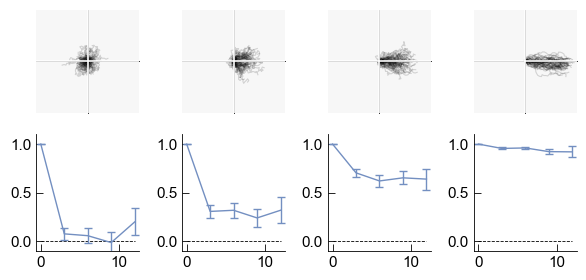

In [107]:

f, ax = plt.subplots(2, 4,figsize=(1.5*len([ 0. ,  0.5,  1. ,  2.]),3))
ax = ax.ravel()

dict_ax = dict(zip([ 0. ,  0.5,  1. ,  2.], [0,1,2,3]))

for g, d in df[df.kappa != 10].groupby('kappa'):
    print(g)
    trajectories = []
    count_cell = 0
    for i, d_ in d.groupby(['cell']):

        t0_x = d_[d_.frame == d_.frame.min()].x.values
        t0_y = d_[d_.frame == d_.frame.min()].y.values
        if len(t0_x) == 0 or len(t0_y) == 0:
            continue

        x_rel = d_.x.values - t0_x[0]
        y_rel = d_.y.values - t0_y[0]

        ax_ = ax[dict_ax[g]]
        ax_.plot(x_rel, y_rel, color='black', alpha=0.15, lw=0.8, zorder=10)

        count_cell += 1

    ax_ = ax[dict_ax[g]]

    # Draw white zero lines to emphasize axes
    ax_.axhline(0, color='white', lw=1.2, zorder=100)
    ax_.axvline(0, color='white', lw=1.2, zorder=100)

    # Enhance axis settings
    ax_.spines['left'].set_position(('data', 0))
    ax_.spines['bottom'].set_position(('data', 0))
    ax_.xaxis.set_label_coords(0.6, -0.05)
    ax_.yaxis.set_label_coords(0.0, 0.6)
    ax_.set_xlim(-130, 130)
    ax_.set_ylim(-130, 130)
    ax_.set_axisbelow(True)
    ax_.set_aspect('equal')  # Equal scaling for x and y
    ax_.set_facecolor('#f7f7f7')  # soft background for contrast

    # Hide y labels if not in leftmost column
    if dict_ax[g] > 0:
        ax_.set_ylabel('')
        ax_.tick_params(labelleft=False)

    # Keep axis labels only on outer left and bottom
    if dict_ax[g] > 0:
        ax_.set_ylabel('')

    # Remove all tick labels
    ax_.set_xticklabels([])
    ax_.set_yticklabels([])

    # Optional: reduce tick mark length
    ax_.tick_params(length=0)

axes = ax[4:]
kappas = [ 0. ,  0.5,  1. ,  2. ]


count = 0
for e, d in df_avg_autocorr[df_avg_autocorr.kappa != 10].groupby('kappa'):
    num_traj = d.num_trajectories.values[0]  # same across lags if consistent
    axes[count].errorbar(
        d.lag, d.mean_autocorr, yerr=d.sem_autocorr,
        label=f"kappa {e} (n={num_traj})", capsize=3, marker='o',markersize=0, linewidth=1
    )
    count +=1

for ax_ in axes:
    # ax_.set_xlim(-0.1, 5*3+0.2)
    ax_.set_ylim(-0.1, 1.1)
    ax_.set_yticks([0,0.5, 1.0])
    ax_.hlines(0,0,4*3, zorder = 0, color = 'k', linestyle = '--')


plt.tight_layout()
f.savefig('../../figures/20250523_compassauto_synthetic_tracks.pdf', bbox_inches='tight')
